# **PREDICTION DES VENTES MENSUELLES**

**MODELE ARIMA**

Le modèle ARIMA (AutoRegressive Integrated Moving Average) est une méthode couramment utilisée pour analyser et prévoir les séries chronologiques. Il s’appuie sur les valeurs passées de la série(modèle AR), les erreurs précédentes (modèle MA) et une transformation des données (différenciation I)  afin de capturer la tendance et la dynamique globale de la série.

**Composantes du modèle ARIMA**:

**AR (Autorégression)**,
cette composante utilise les valeurs passées de la série pour prédire la valeur actuelle. Elle permet de modéliser la dépendance entre les observations dans le temps.

**MA (Moyenne mobile)**,
la composante MA s’appuie sur les erreurs passées du modèle pour ajuster les prévisions. Elle permet de capturer les fluctuations non expliquées par l’autorégression.

**I (Différenciation)**,
la différenciation sert à rendre la série stationnaire en supprimant la tendance et les variations de long terme. Elle consiste à calculer les différences entre observations successives.

**Paramètres du modèle ARIMA**:

Le modèle ARIMA est défini par trois paramètres : p, d et q.

**p** : nombre de valeurs passées utilisées (autorégression)

**d** : nombre de différenciations nécessaires pour stationnariser la série

**q** : nombre d’erreurs passées prises en compte (moyenne mobile


# **Méthodologie**

Elle se déroule en trois grandes étapes :

**1-Identification du modèle**

Analyse des données : examiner la série pour détecter tendances, saisonnalités et anomalies. Dans un sens, étudier la stationnarité

**Différenciation** : si la série n’est pas stable ou stationnaire, appliquer une différenciation pour la rendre stationnaire.

**Choix des ordres (p, d, q)** : utiliser les graphiques ACF et PACF pour déterminer combien de valeurs passées et d’erreurs doivent entrer dans le modèle.

**2-stimation du modèle**

Estimer les paramètres du modèle ARIMA à l’aide de méthodes statistiques (comme les moindres carrés) pour que le modèle corresponde au mieux aux données.

**3-Vérification et validation**

Diagnostic : vérifier que les résidus (erreurs) sont aléatoires et ne présentent pas de structure.

Réajustement : si nécessaire, modifier les ordres du modèle et recommencer.

Validation : tester les performances du modèle à  travers la courbe du residu.

Cette méthodologie est itérative : on répète les étapes jusqu’à obtenir un modèle ARIMA qui capture correctement les motifs de la série et permet de faire des prévisions fiables.

# ***PRÉSENTATION ET CHARGEMENT DES DONNÉES***

Les données sont des séries mensuelles. C'est une base univariée, c'est à dire comportant une seule variable "ventes" et donc adapté à un modèle ARIMA. Elle contient deux colonnes:

**Mois**: date et donc le mois et année de chaque vente

**Vente**: la quantité vendue durant le mois
Les données couvrent janvier 2015 à janvier 2026


# **ÉTAPE 1**: Identification du modèle

In [65]:
##Importation des bibliothèques nécessaires pour le travaille
!pip install pmdarima
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA
import warnings
warnings.filterwarnings("ignore")



In [66]:
#téléchargement du fichier
from google.colab import files
uploaded = files.upload()

Saving Classeur1.xlsx to Classeur1 (1).xlsx


In [67]:
##lecture du fichier importé
df = pd.read_excel('Classeur1.xlsx')

In [68]:
df.head(5)

,Mois,Vente
0,2015-01,14034
1,2015-02,11588
2,2015-03,19736
3,2015-04,20892
4,2015-05,20962


In [5]:
##Vérification des types de données

df.dtypes


,0
Mois,object
Vente,int64


In [69]:

# Transformer 'Mois' en datetime et 'Vente' en numérique
df["Mois"] = pd.to_datetime(df["Mois"], format="%Y-%m")
df["Vente"] = pd.to_numeric(df["Vente"])

In [70]:
# Mettre la colonne 'Mois' comme index
df.set_index("Mois", inplace=True)

# Vérifier le résultat final
print("\nDataFrame nettoyé :")
print(df.head())
print("\nTypes de données :")
print(df.dtypes)


DataFrame nettoyé :
            Vente
Mois             
2015-01-01  14034
2015-02-01  11588
2015-03-01  19736
2015-04-01  20892
2015-05-01  20962

Types de données :
Vente    int64
dtype: object


In [71]:
##Nous sommes arrivés à transformer les données afin d'obtenir le format que nous voulons. La colonne vente devient entier et mois devient date
##Nous cherchons les données manquantes et en double
print("\nles valeurs nules :")
print(df.isnull().sum())
print("\nles valeurs en double :")
print(df.duplicated().sum())


les valeurs nules :
Vente    0
dtype: int64

les valeurs en double :
0


Le resultat montre qu'il n'y a ni de données manquantes ni de doublons

In [72]:
##Description de données
df.describe()

,Vente
count,130.000000
mean,7679.146154
std,3927.636371
min,2494.000000
25%,5217.750000
50%,7053.000000
75%,8826.750000
max,21371.000000


**Explication du Resultat**

count = 130
Nous avons 130 observations, donc 130 mois de ventes.

mean = 7679.15
La vente moyenne mensuelle est d’environ 7 679 unités.

std = 3927.63
L’écart type est assez élevé, presque la moitié de la moyenne.
→ Cela signifie que les ventes varient beaucoup d’un mois à l’autre.

min = 2 994 et max = 21 371
La plus petite vente sur un mois est 2 994, la plus grande 21 371.
→ Les ventes peuvent fortement fluctuer.

25% = 5 217.75, 50% = 7 053, 75% = 8 826.75
Les quartiles :

25 % des mois ont des ventes ≤ 5 217.75

50 % des mois ont des ventes ≤ 7 053 (médiane)

75 % des mois ont des ventes ≤ 8 826.75

En résumé :

Les ventes sont très variables, il y a une grosse différence entre les mois faibles et les mois forts.
Les ventes sont concentrées entre 5 000 et 9 000 la plupart du temps, mais quelques mois très élevés tirent la moyenne vers le haut.

La médiane (7 053) est un peu plus basse que la moyenne (7 679.15), ce qui suggère que la distribution est légèrement décalée vers les valeurs élevées (quelques pics très hauts). Le maximum est très éloigné de la moyenne c'est un outlier (valeur anormale).
Cela explique pourquoi la moyenne est plus élevée que la médiane.

**REPRESENTATION GRAPHIQUE ET ANALYSE DE LA SAISONNALITE**

Nous allons représenter le gaphique de vente et étudier son comportement. Elles sont saisonière ou stables

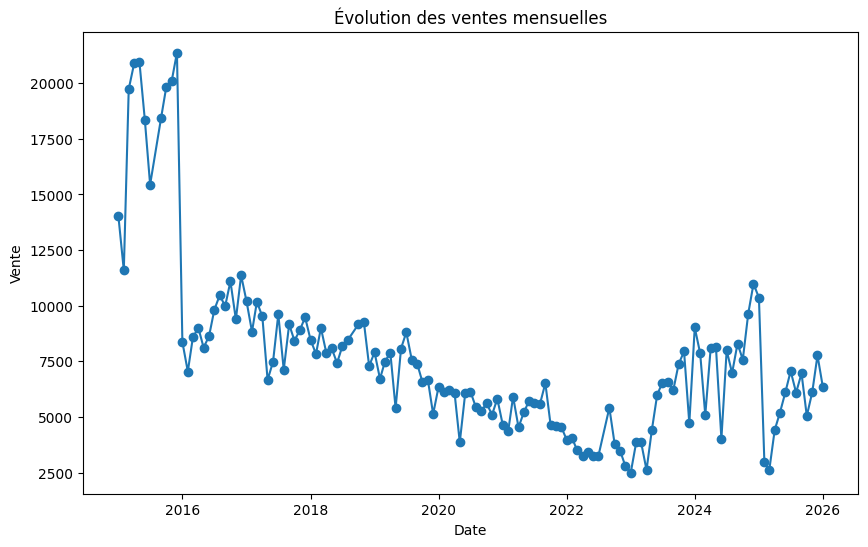

In [73]:
##Graphque d'évolution des ventes durant la période

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Vente'], marker='o', linestyle='-')
plt.title('Évolution des ventes mensuelles')
plt.xlabel('Date')
plt.ylabel('Vente')
plt.grid(False)
plt.show()

ACF et PACF

L’ACF (fonction d’autocorrélation) et la PACF (fonction d’autocorrélation partielle) sont des outils très utiles pour comprendre comment les valeurs d’une série temporelle dépendent des valeurs passées.

ACF (Autocorrelation Function)

L’ACF mesure à quel point les données sont similaires à elles-mêmes à différents décalages dans le temps.

Pour un décalage k, l’ACF indique la corrélation entre la série et elle-même décalée de k périodes.

Exemple : une ACF de 0,9 à k = 2 signifie que la valeur d’aujourd’hui est très similaire à celle d’il y a deux périodes.

PACF (Partial Autocorrelation Function)

La PACF mesure la corrélation en isolant l’effet des valeurs intermédiaires.

Pour un décalage k, la PACF montre la corrélation entre la série et elle-même décalée de k, après avoir retiré l’influence des décalages 1 à k-1.

Exemple : une PACF de 0,5 à k = 3 signifie qu’après avoir pris en compte les 2 périodes précédentes, la valeur d’aujourd’hui et celle d’il y a trois périodes sont moyennement liées.

Ces graphiques servent à:

Les graphes ACF et PACF aident à choisir les paramètres du modèle ARIMA/SARIMA :

L’ACF sert à identifier le terme MA (moyenne mobile)

La PACF sert à identifier le terme AR (auto-régressif)
 **En gros** :

ACF = “c'est comme si nous regardons  tous les effets du passé”

PACF = “ l’effet direct du passé, en enlevant les intermédiaires”

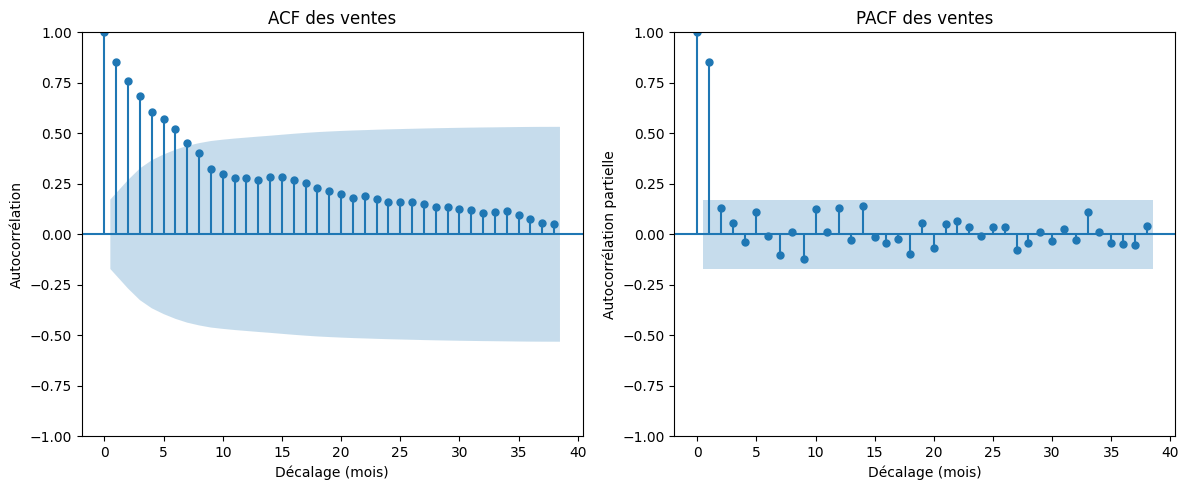

In [74]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Taille des graphiques
plt.figure(figsize=(12,5))

# Graphique ACF: autocorrelation simple
plt.subplot(1,2,1)
plot_acf(df["Vente"], lags=38, ax=plt.gca())
plt.title("ACF des ventes")
plt.xlabel("Décalage (mois)")
plt.ylabel("Autocorrélation")

# Graphique PACF: autocorrelation partielle
plt.subplot(1,2,2)
plot_pacf(df["Vente"], lags=38, ax=plt.gca(), method='ywm')
plt.title("PACF des ventes")
plt.xlabel("Décalage (mois)")
plt.ylabel("Autocorrélation partielle")

plt.tight_layout()
plt.show()

L’analyse des graphiques ACF et PACF montre que les ventes mensuelles sont fortement dépendantes des mois précédents. L’ACF décroît progressivement avec les décalages et les 7 premiers mois sont significatifs, ce qui indique une influence des valeurs passées sur la série. La PACF présente deux barres significatives, la première étant plus élevée, ce qui suggère que les ventes du mois précédent ont le plus d’effet, et le mois d’il y a deux mois a également une influence moindre. Ces résultats indiquent une série principalement auto-régressive avec une mémoire courte, et la présence probable d’une saisonnalité annuelle, comme attendu pour des données mensuelles. Nous allons décomposé la série pour bien cerner les caractéristique: saisonnalité, residu, etc.

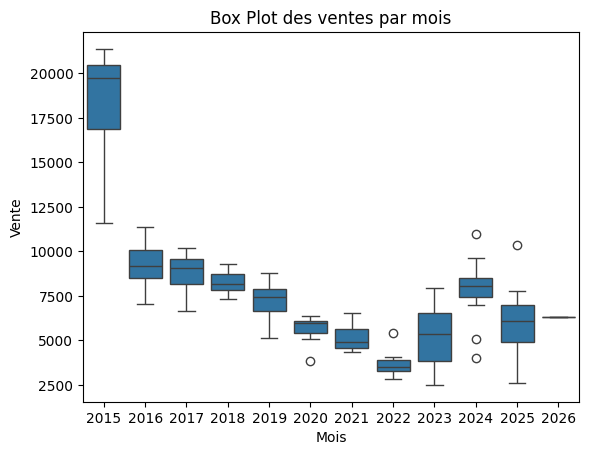

In [75]:
## Box plot
sns.boxplot(x=df.index.year, y=df['Vente'])
plt.title('Box Plot des ventes par mois')
plt.xlabel('Mois')
plt.ylabel('Vente')
plt.show()

In [77]:
##Remplaçons le outlier par la valeur médiane
df.loc["2024-11", "Vente"] = df["Vente"].median()


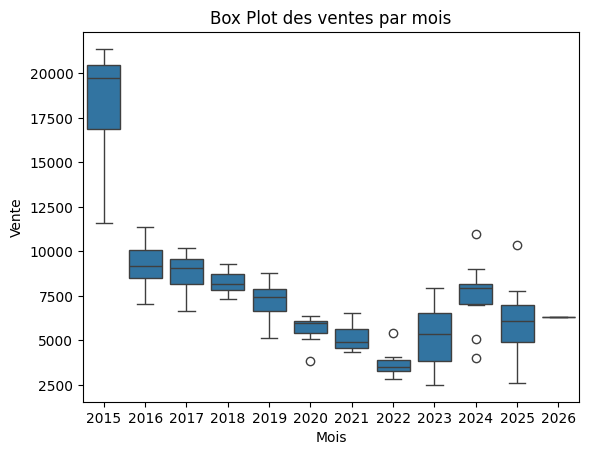

In [78]:
## Box plot
sns.boxplot(x=df.index.year, y=df['Vente'])
plt.title('Box Plot des ventes par mois')
plt.xlabel('Mois')
plt.ylabel('Vente')
plt.show()

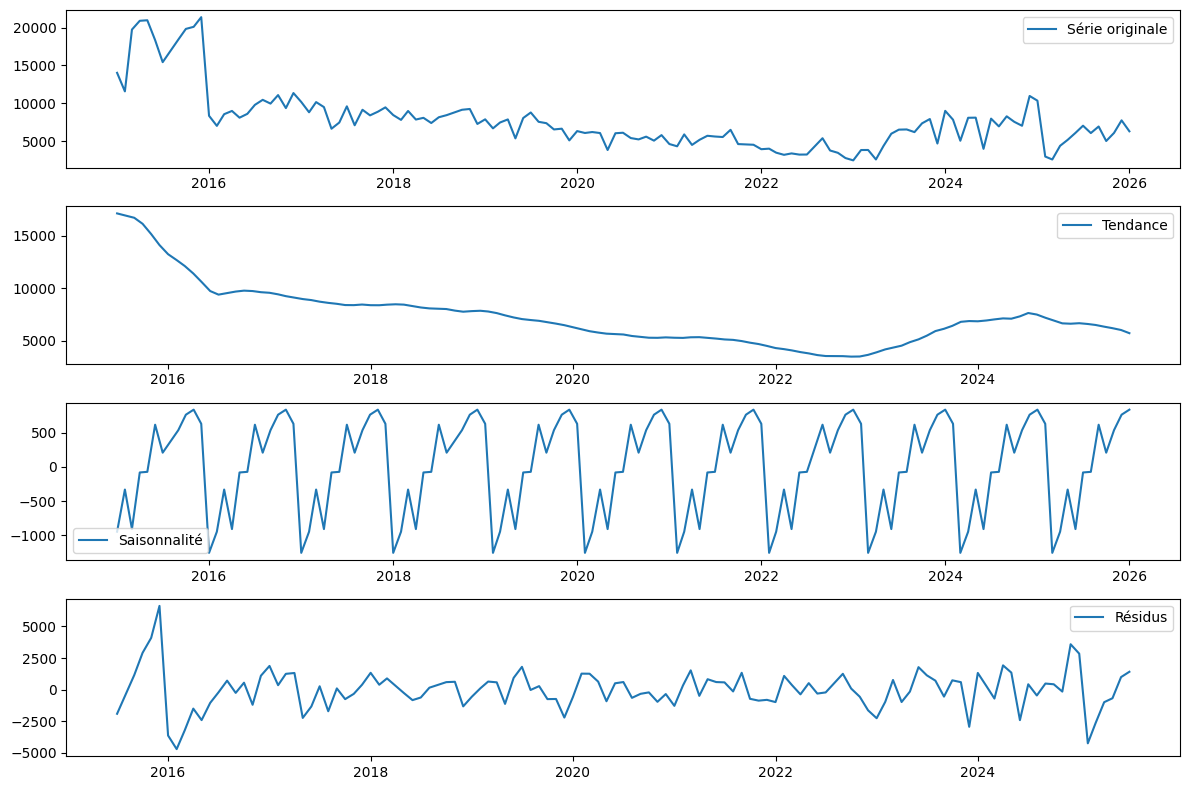

In [79]:
# Effectuer la décomposition saisonnière. Nous choississons le modèle additif puis que les pics sont constant, pas de grandes amplitudes
decomposition = seasonal_decompose(df['Vente'], model='additive', period=12)

# Extraire les composantes de la décomposition
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Afficher les composantes de la décomposition
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df['Vente'], label='Série originale')
plt.legend(loc='best') ##demande à Matplotlib de placer automatiquement la légende à l’endroit où on peut le lire facilement

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='best')

plt.subplot(414)
plt.plot(residual, label='Résidus')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

**Explication du graphique**:

**1️-Tendance**

La ligne de tendance montre que, globalement, les ventes baissent sur le long terme.

Même si certains mois ont des pics, la moyenne générale diminue au fil des années.

Implication : le modèle devra prendre en compte cette baisse pour prévoir correctement les mois futurs.

**2️-Saisonnalité**

Les composantes saisonnières montrent des cycles réguliers : hausse, baisse, hausse… chaque année ou chaque période.

Cela indique que certains mois ont toujours tendance à être plus forts ou plus faibles, indépendamment de la tendance générale. Donc on peut utiliser le modèle SARIMA pour prévoir les ventes

Exemple : si chaque décembre les ventes montent, même si globalement la tendance baisse, SARIMA peut capturer ce pic annuel.

**3️-Résidus**

Les résidus représentent les fluctuations imprévisibles, après avoir retiré tendance et saisonnalité.

Les résidus oscillent autour de zéro et sans motif clair, c’est parfait.

Cela montre que la série est bien expliquée par la tendance et la saisonnalité, et que ce qui reste est aléatoire.

# ***ÉTAPE2: ESTIMATION DU MODELE***

Avant d'estimer le moèle, nous allons d'abord choisir les paramètres p et q de AR et MA.

**1️ Choix des paramètres initiaux**

D’après les graphiques :

AR (p) = 2 → PACF montre deux pics significatifs

MA (q) = 0 → ACF décroît progressivement, pas de pic clair

Saison mensuelle : s = 12 (1 an)

Composantes saisonnières : P=1 (1 pic dans ACF saisonnier), D=1 (pour rendre la saison stable), Q=0

Donc SARIMA(p,d,q)(P,D,Q,s) = (2,1,0)(1,1,0,12)

AN: Pour SARIMA, on a pas besoin de différencier le modèle, on va le faire directaement dans l'estimation et l'ordre 1 suffit.

In [80]:
result_ct = adfuller(df["Vente"], regression='ct')
print("ADF Statistic :", result_ct[0])
print("p-value :", result_ct[1])

ADF Statistic : -3.412331763993989
p-value : 0.04976199494286984


In [81]:
from statsmodels.tsa.stattools import adfuller

# Lancer le test ADF
result = adfuller(df["Vente"])

# Affichage des résultats
print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Lags used :", result[2])
print("Number of observations :", result[3])

for key, value in result[4].items():
    print(f"Critical Value ({key}) : {value}")

ADF Statistic : -3.8244458622570257
p-value : 0.002666874582770517
Lags used : 7
Number of observations : 122
Critical Value (1%) : -3.4851223522012855
Critical Value (5%) : -2.88553750045158
Critical Value (10%) : -2.5795685622144586


**La série présente un changement de régime lié à une hausse puis une baisse des prix, ce qui modifie la dynamique des ventes. Ce type de rupture structurelle n’est pas une saisonnalité et ne correspond pas à une tendance linéaire. Cela explique pourquoi le test ADF sans tendance conclut à la stationnarité, tandis que le test avec tendance ne la détecte pas.**

**Les tests de stationnarité montrent que la série est stationnaire autour d’un niveau, mais pas autour d’une tendance linéaire. L’ACF et la PACF indiquent une dynamique principalement auto‑régressive de faible ordre, sans composante saisonnière. Le modèle le plus approprié est donc un ARIMA(2,0,0), éventuellement comparé à un ARIMA(2,0,1) pour validation via l’AIC.**

**Ou laisser les données choisir**

In [98]:


# Modèle ARIMA avec intercept
model = auto_arima(
    df["Vente"],
    seasonal=False,
    d=0,
    max_p=5,
    max_q=5,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    with_intercept=True  # ← remettre l'intercept
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=2352.190, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2523.397, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=2354.280, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=2430.926, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2726.372, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=2354.236, Time=0.22 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=2355.029, Time=0.28 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=2353.389, Time=0.41 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=2356.055, Time=0.37 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=2353.662, Time=0.13 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=2357.176, Time=0.22 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=2352.212, Time=0.57 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=2.78 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2351.685, Time=0.26 sec
 ARIMA(1,0,2)(0,0,0)[0]             : 

**Interprétation du modèle ARIMA**

Le modèle ARIMA(2,1,0)x(1,1,0,12) a été ajusté sur 130 mois de ventes.

Coefficients estimés :

ar.L1 = 0.997 : proche de 1. la valeur du mois précédent influence positivement les ventes du mois courant.

ma.L1 = -0.244 : la valeur d’il y a un mois influence également le mois courant, moins fortement.

ar.L12 = -0.222 : même chose pour l'erreur d'il y deux mois.

Tous les coefficients sont statistiquement significatifs (p < 0.000).

Statistiques résiduelles :

Le test de Ljung-Box (Q=0.3, p=0.72) montre que les résidus ne présentent pas d’autocorrélation significative, donc le modèle capture bien la dépendance temporelle.

Le test Jarque-Bera (JB=739.29, p=0.00) indique que les résidus ne suivent pas exactement une distribution normale, ce qui est courant pour des données économiques ou de vente.

La variance des résidus sigma2 = 8.11e-09 montre l’amplitude des fluctuations non expliquées par le modèle.

Conclusion :

Le modèle ARIMA choisi capture la tendance, la dépendance des valeurs passées et la saisonnalité annuelle.

Les résidus sont globalement aléatoires, ce qui signifie que le modèle est adéquat pour prévoir les ventes mensuelles sur la période suivante.

# **ÉTAPES 3: PRÉVISION**

**Nous allons prévoir les données de février 2026 à décembre 2026**

In [101]:
# Le modèle est déjà estimé par auto_arima et stocké dans 'model'

# Afficher le résumé du modèle
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  130
Model:               SARIMAX(1, 0, 2)   Log Likelihood               -1170.995
Date:                Tue, 24 Feb 2026   AIC                           2349.991
Time:                        09:48:01   BIC                           2361.461
Sample:                             0   HQIC                          2354.651
                                - 130                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9972      0.004    226.568      0.000       0.989       1.006
ma.L1         -0.2443      0.065     -3.748      0.000      -0.372      -0.117
ma.L2         -0.3186      0.072     -4.435      0.0

In [108]:
## faire la prévision de 11 prochains mois
steps = 6
future_index = pd.date_range(start='2026-02-01', periods=steps, freq='MS')

# Get predictions and confidence intervals from the 'model'
# The model was fitted on 'Vente', so no exp() needed
forecast_values_raw, forecast_ci_raw = model.predict(n_periods=steps, return_conf_int=True)

# Convert to pandas Series/DataFrame with correct index
forecast_values = pd.Series(forecast_values_raw.values, index=future_index) # Corrected line: use .values
forecast_ci = pd.DataFrame(forecast_ci_raw, index=future_index, columns=['lower', 'upper'])

## création dans un dataframe pour affichage
forecast_df = pd.DataFrame({
    "Vente_prévue": forecast_values,
    "IC_inf": forecast_ci['lower'],
    "IC_sup": forecast_ci['upper']
})

print(forecast_df)

            Vente_prévue       IC_inf        IC_sup
2026-02-01   6056.674985  2241.762335   9871.587636
2026-03-01   6281.949091  1506.596825  11057.301356
2026-04-01   6264.294024  1212.310041  11316.278008
2026-05-01   6246.688577   933.889327  11559.487827
2026-06-01   6229.132608   669.100592  11789.164624
2026-07-01   6211.625980   416.197801  12007.054158


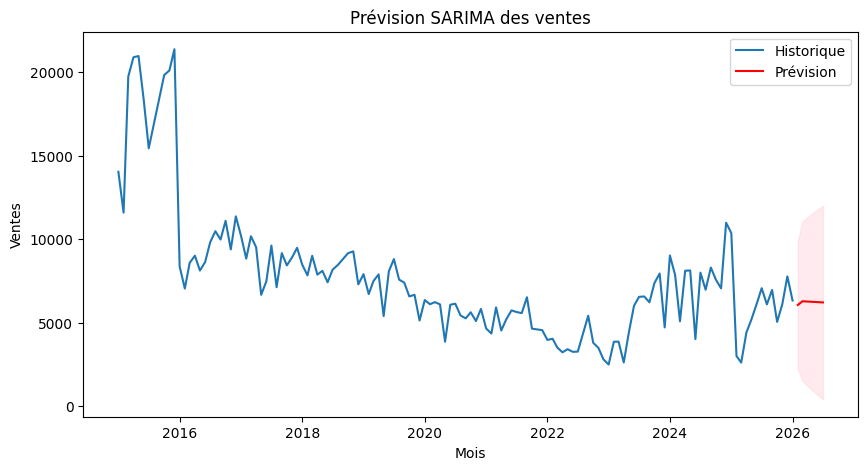

In [109]:
##Tracer la courbe

plt.figure(figsize=(10,5))
plt.plot(df["Vente"], label="Historique")
plt.plot(forecast_values, label="Prévision", color='red')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='pink', alpha=0.3)
plt.title("Prévision SARIMA des ventes")
plt.xlabel("Mois")
plt.ylabel("Ventes")
plt.legend()
plt.show()


**ÉTAPE 4: VALIDATION DU MODELE**

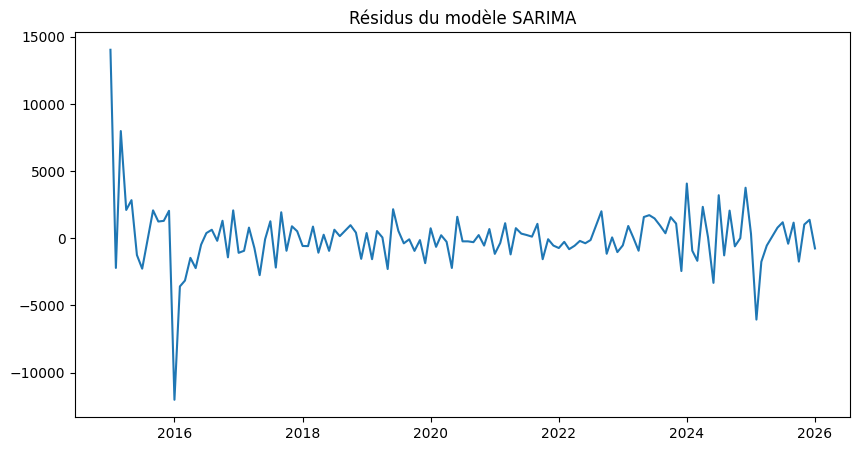

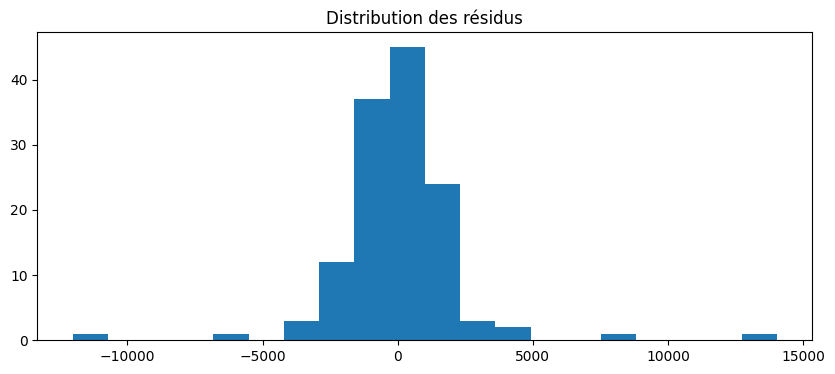

In [112]:
# Graphique des résidus
residuals = model.resid()

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Résidus du modèle SARIMA")
plt.show()

# Histogramme des résidus pour vérifier la normalité
plt.figure(figsize=(10,4))
plt.hist(residuals, bins=20)
plt.title("Distribution des résidus")
plt.show()

***Les résidus fluctuent autour de la moyenne et sont normalement distribués. Le modèle est globalement bon***.

**CONCLUSION**

Cette étude a permis de modéliser et de prévoir les ventes mensuelles à l’aide d’un modèle ARIMA, en tenant compte de la tendance, de la dépendance temporelle et de la saisonnalité annuelle. Les résultats montrent que le modèle capture correctement les dynamiques internes de la série, comme le confirment la significativité des coefficients estimés et l’absence d’autocorrélation résiduelle notable.

Cependant, il est essentiel de souligner que les prévisions issues de ce type de modèle reposent sur une hypothèse fondamentale de continuité : le futur est supposé prolonger les comportements observés dans le passé. Dans ce cadre, le modèle ne peut anticiper les chocs exogènes majeurs, les ruptures structurelles ou les événements exceptionnels.

Ainsi, les résultats obtenus doivent être interprétés comme des scénarios probabilistes conditionnels, et non comme des certitudes. L’intégration d’intervalles de confiance (ien qu'il soit instable à cause de non normalité des erreurs) permet précisément de quantifier cette incertitude et de rappeler que toute prévision est, par nature, imparfaite. En pratique, ces modèles constituent des outils d’aide à la décision, utiles dans un environnement relativement stable, mais qui doivent être complétés par une analyse qualitative, une veille économique et une capacité d’adaptation face à l’imprévu.

En définitive, la valeur d’un modèle ne réside pas dans sa capacité à prédire les crises, mais dans sa faculté à décrire la structure d’un système en régime normal et à expliciter clairement ses propres limites.